# Model Testing

# Packages

In [1]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
from tqdm import tqdm as tqdm
import warnings


# GIN
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool, global_mean_pool, global_max_pool
from torch.nn import Linear, Sequential, ReLU
import torch.nn.functional as F
from torch_geometric.utils import from_networkx

# uMAP
import umap.umap_ as umap

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\roman\AppData\Lo

# Directories

# Functions

In [2]:
def gin_get_embeddings(model, loader):
    '''
    Takes a loader and GIN model, and generates 4 forms of graph embeddings; raw, centered, normalised and centered + normalised.
    '''

    # Initialise embeddings
    embeddings = []

    # Set model to evaluation mode
    model.eval()

    # Disable gradient tracking to save memory
    with torch.no_grad():
        # Iterate through batches
        for batch in loader:
            # Generate embeddings
            emb = model(batch.x, batch.edge_index, batch.batch)
            # Append data
            embeddings.append(emb)
    
    # Concatenate all batch output
    embeddings = torch.cat(embeddings, dim = 0)

    # Centered embeddings
    emb_center = embeddings - embeddings.mean(axis = 0, keepdims = True)
    # Normalised embeddings
    emb_norm = F.normalize(embeddings, p = 2, dim = 1)
    # Center and normalise
    emb_centernorm = F.normalize(emb_center, p = 2, dim = 1)

    return embeddings, emb_center, emb_norm, emb_centernorm

def plot_text_labels(dataframe, attribute_name):
    '''
    Extracts column data from a dataframe w/ x,y coordinates and returns list of formatted labels.
    '''

    # Initialise list
    list_labels = []

    for index, row in dataframe.iterrows():
        # Get label data
        label = row[attribute_name]
        # Get coordinates
        x, y = row['x'], row['y']
        
        # Label style
        label_style = {'fontsize' : 16,
                       'weight' : 'bold',
                       'color' : 'black',
                       'alpha' : 1,
                       'ha' : 'center',
                       'va' : 'bottom',
                       'bbox' : {'facecolor' : 'whitesmoke',
                                 'edgecolor' : 'black',
                                 'alpha' : 0.25,
                                 'boxstyle' : 'round, pad = 0.1'}}

        # Append data w/ styling
        list_labels.append(plt.text(x, y, label, **label_style))

    return list_labels

def umap_get_embeddings(embeddings, graph_list):
    '''
    Takes a set of embedding vectors and returns a dataframe of uMAP embeddings w/ attribute values for graphs.
    '''

    # Generate embeddings
    umap_embedding = umap.UMAP(metric = 'cosine', random_state = 42).fit_transform(embeddings)
    # Get attribute values from graphs
    list_attr = [graph.mean for graph in graph_list]

    # Convert to dataframe
    df = pd.DataFrame(umap_embedding, columns = ['x', 'y'])
    # Add attribute column
    df['mean_dexp'] = list_attr

    return df

def umap_visualise(dataframe, title = None):
    '''
    Takes dataframe output of umap_get_embeddings and plots a labelled seaborn scatterplot.
    '''

    plt.figure(figsize = (10,10))
    plt.title(f'{title}', fontsize = 16)
    sns.scatterplot(dataframe, x = 'x', y = 'y', color = 'dimgrey', edgecolor = 'black', s = 200)
    # Generate point labels
    list_labels = plot_text_labels(dataframe, 'mean_dexp')
    # Plot labels
    adjust_text(list_labels,
                arrowprops = dict(arrowstyle = '-',
                                  color = 'dimgrey',
                                  lw = 0.25))
    
    # Remove axis
    plt.axis('off');
    plt.show()

# Generate graphs

In [30]:
# Variables
N_NODES = 900
N_GRAPHS = 32

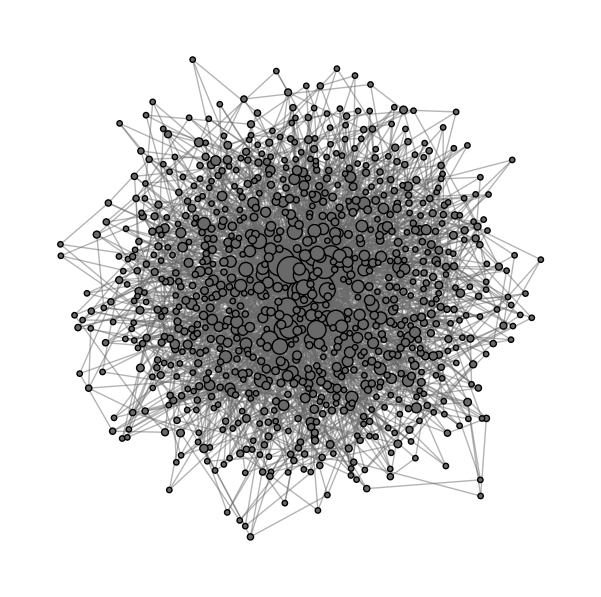

In [31]:
# Create test graph
graph_test = nx.barabasi_albert_graph(n = N_NODES, m = 3, seed = 42)

# Assign initial 'dexp' values
for node in graph_test.nodes:
    graph_test.nodes[node]['dexp'] = 1

# Generate positional data
pos = nx.spring_layout(graph_test, k = 0.1)
# Get degree values
list_degree = [nx.degree(graph_test, node) * 5 for node in graph_test.nodes]

# Draw graph
plt.figure(figsize = (7.5,7.5))
nx.draw_networkx_edges(graph_test, pos = pos, alpha = 0.5, edge_color = 'dimgrey')
nx.draw_networkx_nodes(graph_test, pos = pos, node_size = list_degree, edgecolors = 'black', node_color = 'dimgrey')
plt.axis('off');

## Set level

### Calculate

In [32]:
# Define values
list_values = range(0, N_GRAPHS, 1)
# Initialise list_set
list_set = []

# Iterate through list_values
for value in list_values:
    # Copy graph_test
    graph_copy = graph_test.copy()
    # Assign 'dexp' values
    for node in graph_copy.nodes:
        graph_copy.nodes[node]['dexp'] = value
    # Append data
    list_set.append(graph_copy)
    #list_set.append(graph_copy)

### Visualise

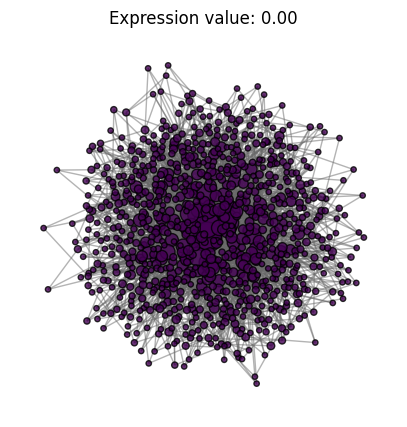

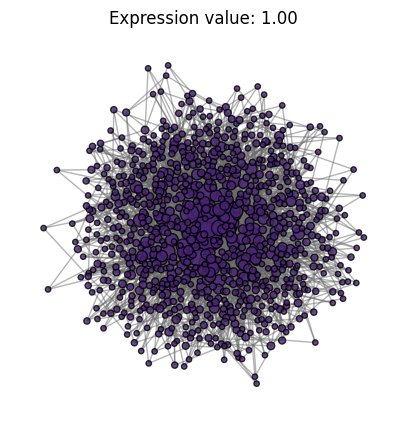

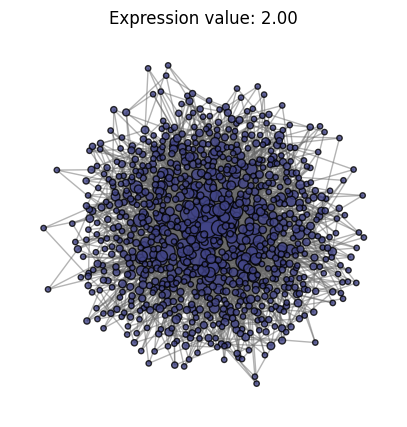

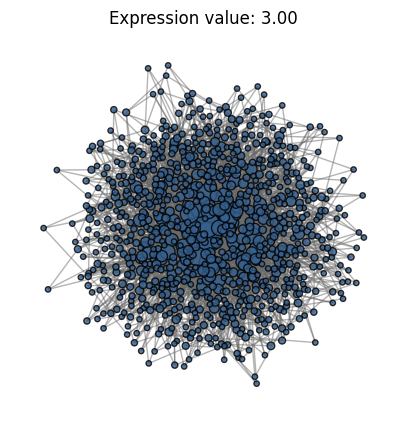

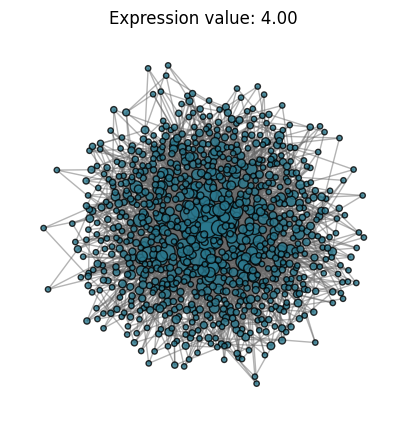

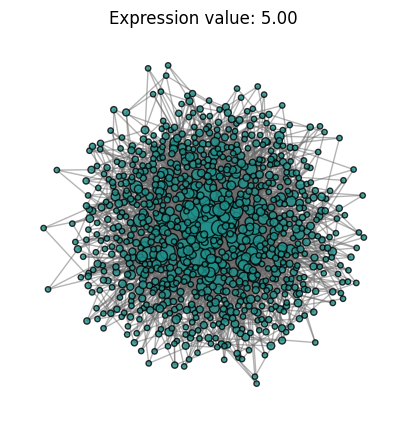

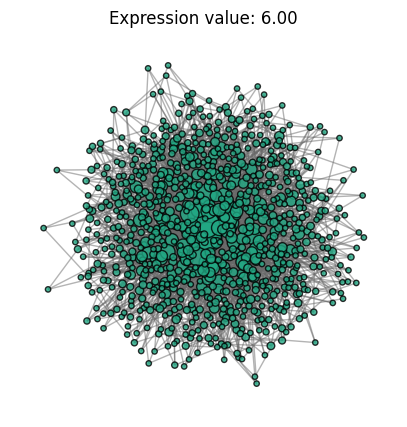

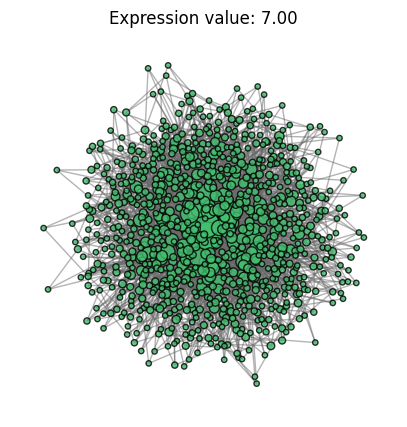

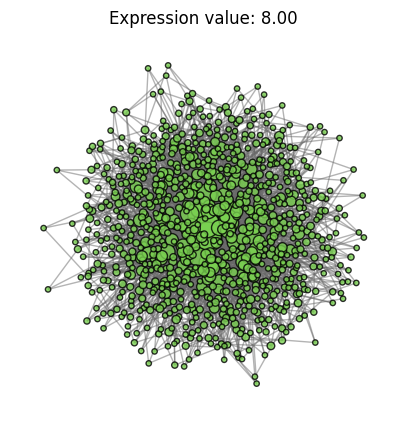

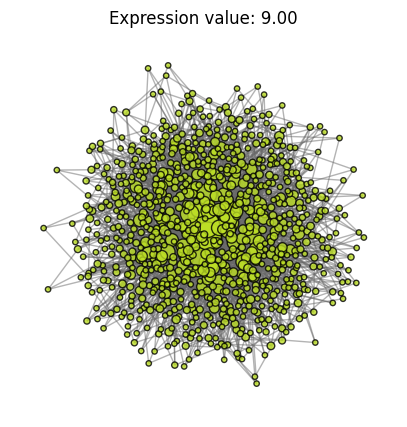

In [11]:
for graph in list_set:
    # Get dexp values
    list_dexp = [graph.nodes[node]['dexp'] for node in graph.nodes]
    # Get mean value
    mean_dexp = np.mean(list_dexp)
    
    # Visualise
    plt.figure(figsize = (5,5))
    plt.title(f'Expression value: {mean_dexp:.2f}')
    nx.draw_networkx_edges(graph, pos = pos, alpha = 0.5, edge_color = 'dimgrey')
    nx.draw_networkx_nodes(graph, pos = pos, node_size = list_degree, edgecolors = 'black', node_color = list_dexp, alpha = 0.8, cmap = 'viridis', vmin = 0, vmax = N_GRAPHS)
    plt.axis('off');
    plt.show()

## Defined noise

## Random noise

# Convert to PyG

In [33]:
# Variables
INPUT_LIST = list_set

# Initialise PyG graphlise
list_pyg = []

# Iterate through list
for graph in INPUT_LIST:
    # Get mean dexp
    mean_dexp = np.mean([graph.nodes[node]['dexp'] for node in graph.nodes])
    # Convert to PyG object
    pyg = from_networkx(graph, group_node_attrs = ['dexp'])
    # Format 'dexp' attribute
    pyg.mean = f'{mean_dexp}'
    # Append to graph list
    list_pyg.append(pyg)

# GIN

## GIN only

### Define model

3 different types of global pooling are included to generate graph embeddings:

1. **Global Mean Pooling**
- Averages all node embeddings in each graph
- Captures the "average" feature distribution
- Loses information about extreme nodes
- May blur differences if only a few nodes carry important signals

2. **Global Sum Pooling**
- Sums all node embeddings in each graph
- Good when node features are additive (e.g. counts, cumulative signals)
- Graph size heavily influences embedding (can dominate similarity)

3. **Global Max Pooling**
- Takes the maximum value across nodes for each feature dimension
- Highlights the most "activated" or extreme node features
- Useful when rare but strong signals matter (e.g. outlier expression)
- Can be unstable if noisy features dominate


In [8]:
# Define GIN
class GIN(torch.nn.Module):
    
    def __init__(self, num_node_features, hidden_dim, out_dim, pooling_type = 'mean'):
        super(GIN, self).__init__()

        # Save pooling type
        self.pooling_type = pooling_type

        # First GINConv layer
        nn1 = torch.nn.Sequential(torch.nn.Linear(num_node_features, hidden_dim),
                                  torch.nn.ReLU(),
                                  torch.nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn1)

        # Second GINConv layer
        nn2 = torch.nn.Sequential(torch.nn.Linear(hidden_dim, hidden_dim),
                                  torch.nn.ReLU(),
                                  torch.nn.Linear(hidden_dim, hidden_dim))
        self.conv2 = GINConv(nn2)

        # Final linear layer to project to embedding space
        self.fc_out = torch.nn.Linear(hidden_dim, out_dim)
    
    def forward(self, x, edge_index, batch):

        # Pass through first GINConv
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        # Pass through second GINConv
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Pool node embeddings into graph embedding
        if self.pooling_type == 'mean':
            graph_emb = global_mean_pool(x, batch)
        elif self.pooling_type == 'sum':
            graph_emb = global_add_pool(x, batch)
        elif self.pooling_type == 'max':
            graph_emb = global_max_pool(x, batch)
        elif self.pooling_type == 'all':
            mean_emb = global_mean_pool(x, batch)
            sum_emb = global_add_pool(x, batch)
            max_emb = global_max_pool(x, batch)
            graph_emb = torch.cat([mean_emb, sum_emb, max_emb], dim = 1)

        # Final projection
        return self.fc_out(graph_emb)

### Run model

In [9]:
# # Load data
# loader = DataLoader(list_pyg, batch_size = 32, shuffle = False)

# # Define number of node features
# num_node_features = list_pyg[0].num_node_features
# # Define hidden dimensions
# hidden_dim = 64
# # Define dimensionality of graph embeddings
# out_dim = 32

# # Initialise model
# model = GIN(num_node_features, hidden_dim, out_dim, pooling_type = 'mean')

# # Initialise embeddings
# embeddings = []

# # Set model to evaluation mode
# model.eval()

# # Disable gradient tracking to save memory
# with torch.no_grad():
#     # Iterate through batches
#     for batch in loader:
#         # Generate embeddings
#         emb = model(batch.x, batch.edge_index, batch.batch)
#         # Append data
#         embeddings.append(emb)

# # Concatenate all batch output
# embeddings = torch.cat(embeddings, dim = 0)

# # Center embeddings
# embeddings_center = embeddings - embeddings.mean(axis = 0, keepdims = True)
# # Normalise embeddings (row-wise L2 normalisation)
# embeddings_norm = F.normalize(embeddings, p = 2, dim = 1)
# # Center and normalise
# embeddings_cnorm = F.normalize(embeddings_center, p = 2, dim = 1)

In [36]:
warnings.filterwarnings('ignore')

# Load data
loader = DataLoader(list_pyg, batch_size = 32, shuffle = False)

# Define number of node features
num_node_features = list_pyg[0].num_node_features
# Define hidden dimensions
hidden_dim = 64
# Define dimensionality of graph embeddings
out_dim = 32

# Initialise model
model = GIN(num_node_features, hidden_dim, out_dim)

# Generate embeddings
emb, emb_center, emb_norm, emb_centernorm = gin_get_embeddings(model, loader)

# Initialise umap results
df_umap = pd.DataFrame()

# Define embedding list
list_embeddings = [emb, emb_center, emb_norm, emb_centernorm]
list_labels = ['raw', 'centered', 'normalised', 'centered + normalised']

# Iterate over embedding types
for emb_type, label in zip(list_embeddings, list_labels):
    # Run umap
    df_emb = umap_get_embeddings(emb_type, list_pyg)
    # Add column
    df_emb['emb_type'] = label
    # Concatenate
    df_umap = pd.concat([df_umap, df_emb])

# # Iterate over embedding types
# for emb_type in list_labels:
#     # Slice dataframe
#     df_slice = df_umap[df_umap['emb_type'] == emb_type]
#     # Visualise
#     umap_visualise(df_slice, title = emb_type)

# Iterate over vectors
for emb_type, label in zip(list_embeddings, list_labels):
    # Generate similarity matrices
    sim_matrix = emb_type @ emb_type.t()
    # Generate distance matrix
    dist_matrix = 1.0 - sim_matrix
    # Fill diagonal
    dist_matrix.fill_diagonal_(float('inf'))

    # Generate dictionary of expected neighbours
    expected_neighbors = {
        i: [j for j in [i-1, i+1] if 0 <= j < len(emb_type)]
        for i in range(len(emb_type))
    }
    # Calculate actual ranking
    actual_ranks = torch.argsort(dist_matrix, dim=1)
    
    # Define ideal scores
    ideal_scores = [0.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.0]

    # Initialise divergence score list
    list_divergence = []
    # Iterate over vector
    for i in range(len(emb_type)):
        expected = expected_neighbors[i]
        actual = actual_ranks[i].tolist()
        # Get rank positions of expected neighbors
        ranks = [actual.index(j) for j in expected]
        # Lower rank = closer; ideal ranks are [0, 1]
        divergence = sum(ranks) / len(ranks)  # average rank of expected neighbors
        list_divergence.append(divergence)

    # Calculate mean squared error
    mse = np.mean((np.array(list_divergence) - np.array(ideal_scores))**2)
    src = spearmanr(list_divergence, ideal_scores).correlation

    # Visualise matrix
    # plt.figure(figsize = (10,10))
    # plt.title(f'{label}', fontsize = 16)
    # sns.heatmap(dist_matrix, cmap = 'coolwarm', linewidth = 0.5, linecolor = 'whitesmoke', annot = True, annot_kws = dict(fontsize = 7), fmt = '.1e')
    # plt.show()

    # Visualise divergence
    # plt.figure(figsize = (10,10))
    # plt.title(f'{label}', fontsize = 16)
    # sns.barplot(list_divergence, color = 'dodgerblue', edgecolor = 'black', alpha = 0.5)
    # plt.axhline(y = 0.5, linestyle = 'dashed', color = 'black')
    # plt.ylim(0,10)
    # plt.show()
    # print(list_divergence)

    # Report
    print(f'{label}')
    # Low is better
    print(f'Mean Standard Error: {mse}')
    # High is better
    print(f'Spearman Rank Correlation: {src}')
    print()

raw
Mean Standard Error: 20.4
Spearman Rank Correlation: 0.0

centered
Mean Standard Error: 2.8
Spearman Rank Correlation: 0.7071067811865476

normalised
Mean Standard Error: 2.15
Spearman Rank Correlation: 0.7453559924999299

centered + normalised
Mean Standard Error: 0.625
Spearman Rank Correlation: 0.7115680669648201



# Learning GIN

In [34]:
# Variables
N_HIDDEN_DIMS = 64
N_OUTPUT_DIMS = 64
N_LAYERS = 3
POOLING_TYPE = 'mean'
N_EPOCHS = 10
BATCH_SIZE_TRAINING = 8
BATCH_SIZE_EXTRACTION = 32
NOISE_SCALE = 0.1
#N_RUNS

In [14]:
def augment_gaussian(graph, noise_scale = NOISE_SCALE):
    '''
    Takes a PyG graph, applies random Gaussian noise to the 'x' node feature values, and returns a cloned graph with the augmented node feature values.
    '''

    # Generate augmented values
    augmented_values = graph.x + noise_scale * torch.randn_like(graph.x)
    # Clone graph
    graph_clone = graph.clone()
    # Apply augmented values to graph clone
    graph_clone.x = augmented_values

    return graph_clone

def augment_batch(batch, noise_scale = NOISE_SCALE):
    '''
    Takes a batch object of PyG graphs, generates a augmented version of each graph in the batch, and returns the augmented batch object.
    '''

    # Get node feature values
    values = batch.x.clone()
    # Apply gaussian augmentation
    batch_augmented = augment_gaussian(batch, noise_scale = noise_scale)

    return batch_augmented

def contrastive_loss(z1, z2, temperature = 0.5):
    '''
    Takes an original graphs and augmented copies, and calculates NT-Xent (SimCLR-style) contrastive loss between positive/negative pairs
    '''

    # Normalise embeddings along feature dimension
    z1_norm = F.normalize(z1, dim = 1)
    z2_norm = F.normalize(z2, dim = 1)

    # Get number of graphs in batch
    N = z1.size(0)

    # Concatenate original and augmented embeddings
    Z = torch.cat([z1_norm, z2_norm], dim = 0)

    # Compute pairwise cosine similarity between all embeddings
    sim = torch.matmul(Z, Z.T) / temperature

    # Mask diagonal values in matrix (self-similarity)
    mask = torch.eye(2*N, device = Z.device).bool()
    # Replace diagonal values w/ negative values to be ignored
    sim.masked_fill_(mask, -9e15)

    # Define positive pairs (i, j)
    # Positive pair for i in z1_norm is i+N in z2_norm
    # Positive pair for j in z2_norm is j-N in z1_norm
    targets = torch.arange(N, device = Z.device)
    pos_indices = torch.cat([targets + N, targets], dim = 0)

    # Apply cross-entropy loss, where correct class is positive index, and embeddings are encouraged to select this index among all others
    loss = F.cross_entropy(sim, pos_indices)

    return loss

def preprocess_graph_list(list_pyg):
    '''
    Takes list of PyG graphs, checks for 2D 'x' node feature in each graph, and returns updated list.
    '''

    # Iterate through graphs
    for graph in list_pyg:
        # Check 'x' feature
        if getattr(graph, 'x', None) is None and getattr(graph, 'dexp', 'None') is not None:
            # Get dexp values
            x = graph.dexp.float()
            # Check dimensionality of 'x'
            if x.dim() == 1:
                x = x.view(-1, 1)
            # Set 'x' feature values
            graph.x = x
        
        else:
            x = graph.x.float()
            
            if x.dim() == 1:
                x = x.view(-1, 1)
            
            graph.x = x
    
    return list_pyg

In [15]:
# Define encoder
class GINEncoder(torch.nn.Module):

    def __init__(self, input_dim = 1, hidden_dim = 64, num_layers = 3, pooling_type = 'mean', out_dim = None):
        super().__init__()

        # Save pooling type
        self.pooling_type = pooling_type

        # Built GINConv layers
        self.convs = torch.nn.ModuleList()
        # Iterate through num_layers
        for i in range(num_layers):
            # Check if first layer
            if i == 0:
                # If so, set input dimensions as input_dim i.e. single node feature value
                in_dim = input_dim
            else:
                # If not, set input dimensions as hidden_dim
                in_dim = hidden_dim
        
            # Define MLP used inside GINConv
            mlp = Sequential(
                            # Fully connected layer mapping input dimension into hidden_dim space
                            Linear(in_dim, hidden_dim),
                            # Non-linear activation function
                            ReLU(),
                            # Fully connected later that refines hidden representation
                            Linear(hidden_dim, hidden_dim)
                            )
            
            # Wrap MLP in GINConv layer
            conv = GINConv(mlp)

            # Append convolutional layer to list
            self.convs.append(conv)

        # Generate out_dim vector (uses out_dim value or hidden_dim value if out_dim = None)
        self.proj = Linear(hidden_dim, out_dim if out_dim is not None else hidden_dim)
    
    def forward(self, x, edge_index, batch):
        '''
        Passes node features through each GINConv layer in sequence.
        '''

        # Iterate through GINConv layers
        for conv in self.convs:
            # Aggregate neighbour information and apply MLP
            x = conv(x, edge_index)
            # Apply non-linearity
            x = F.relu(x)

        # Check pooling_type parameter
        if self.pooling_type == 'mean':
            # Average node features per graph
            graph_level_embedding = global_mean_pool(x, batch)
        
        elif self.pooling_type == 'sum':
            # Sum node features per graph
            graph_level_embedding = global_add_pool(x, batch)
        
        elif self.pooling_type == 'max':
            # Take max node features per graph
            graph_level_embedding = global_max_pool(x, batch)

        # elif self.pooling_type == 'all':
        #     # Concatenate mean/sum/max pooling
        #     graph_level_embedding = torch.cat([global_mean_pool(x, batch),
        #                                        global_add_pool(x, batch),
        #                                        global_max_pool(x, batch)],
        #                                        dim = 1)
        
        else:
            # Invalid pooling_type error
            raise ValueError(f'Unknown pooling_type: {self.pooling_type}')
    
        return self.proj(graph_level_embedding)

In [16]:
def gin_train(list_graphs, 
              input_dim = 1,
              hidden_dim = N_HIDDEN_DIMS,
              out_dim = N_OUTPUT_DIMS,
              num_layers = N_LAYERS,
              pooling_type = POOLING_TYPE,
              epochs = N_EPOCHS,
              batch_size = BATCH_SIZE_TRAINING,
              lr = 1e-3,
              noise_scale = NOISE_SCALE, 
              device = None,
              report = False):
    '''
    Takes a list of PyG graph objects and returns trained GINEncoder, using contrastive learning.
    '''

    # Select device (GPU if available, else CPU)
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    # Preprocess graph list
    list_processed = preprocess_graph_list(list_graphs)

    # Create DataLoader to batch random graphs
    loader = DataLoader(list_processed, batch_size = batch_size, shuffle = True)

    # Initialise encoder
    encoder = GINEncoder(input_dim = input_dim,
                         hidden_dim = hidden_dim,
                         num_layers = num_layers,
                         pooling_type = pooling_type,
                         out_dim = out_dim).to(device)
    
    # Define Adam optimiser to update encoder parameters throughout training
    opt = torch.optim.Adam(encoder.parameters(), lr = lr)

    # Activate encoder in training mode
    encoder.train()

    # Iterate through epochs
    for epoch in tqdm(range(epochs), desc = f'Training GIN for {N_EPOCHS} epochs', total = N_EPOCHS):

        # Initialise total loss for report
        total_loss = 0.0

        # Iterate over batches
        for batch in loader:

            # Move batch to device
            batch = batch.to(device)

            # Generate augmented version of batch
            batch_augmented = augment_batch(batch, noise_scale = noise_scale)

            # Define z1 as original batch
            z1 = encoder(batch.x, batch.edge_index, batch.batch)
            # Define z2 as augmented batch
            z2 = encoder(batch_augmented.x, batch_augmented.edge_index, batch_augmented.batch)
            # Compute contrastive loss
            loss = contrastive_loss(z1, z2, temperature = 0.5)

            # Reset gradients before backpropagation
            opt.zero_grad()
            # Backpropagate loss to compute gradients for encoder parameters
            loss.backward()
            # Update encoder parameters w/ Adam optimiser
            opt.step()
            # Sum loss for report
            total_loss += loss.item()
        
        # Print average loss per epoch (optional)
        if report == True:
            print(f'Epoch {epoch + 1}/{epochs} | Loss: {total_loss / len(loader):.4f}')
    
    return encoder

def gin_extract_embeddings(encoder, list_graphs, device = None):
    '''
    Takes trained GIN encoder and applies to list of PyG graph objects, returns graph embeddings.
    '''

    # Choose device
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    # Activate encoder in evaluation mode
    encoder.eval()

    # Preprocess list_graphs
    list_processed = preprocess_graph_list(list_graphs)

    # Create DataLoader to batch graphs
    loader = DataLoader(list_processed, batch_size = BATCH_SIZE_EXTRACTION, shuffle = False)

    # Initialise list to collect embeddings from each batch
    list_embeddings = []

    # Disable gradient tracking (no training, only inference)
    with torch.no_grad():

        # Iterate over batches
        for batch in loader:

            # Move batch to device
            batch = batch.to(device)

            # Generate batch embedding
            batch_embedding = encoder(batch.x, batch.edge_index, batch.batch)
            # Move embeddings to CPU and store
            list_embeddings.append(batch_embedding.cpu())
    
    # Concatenate all batch embeddings
    emb_raw = torch.cat(list_embeddings, dim = 0)
    # Center embeddings
    emb_center = emb_raw - emb_raw.mean(axis = 0, keepdims = True)
    # Normalise embeddings
    emb_norm = F.normalize(emb_raw, p = 2, dim = 1)
    # Center and normalise
    emb_centernorm = F.normalize(emb_center, p = 2, dim = 1)

    return emb_raw, emb_center, emb_norm, emb_centernorm

In [35]:
# Preprocess graph_list
list_processed = preprocess_graph_list(list_pyg)

# Train GIN
trained_gin = gin_train(list_processed, report = True)

# Apply trained GIN
emb_raw, emb_center, emb_norm, emb_centernorm = gin_extract_embeddings(trained_gin, list_pyg)

Training GIN for 10 epochs:  40%|████      | 4/10 [00:00<00:00, 17.43it/s]

Epoch 1/10 | Loss: 2.6696
Epoch 2/10 | Loss: 2.6178
Epoch 3/10 | Loss: 2.6097
Epoch 4/10 | Loss: 2.6045
Epoch 5/10 | Loss: 2.6017
Epoch 6/10 | Loss: 2.6009


Training GIN for 10 epochs: 100%|██████████| 10/10 [00:00<00:00, 21.47it/s]

Epoch 7/10 | Loss: 2.6003
Epoch 8/10 | Loss: 2.5994
Epoch 9/10 | Loss: 2.5979
Epoch 10/10 | Loss: 2.5942


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


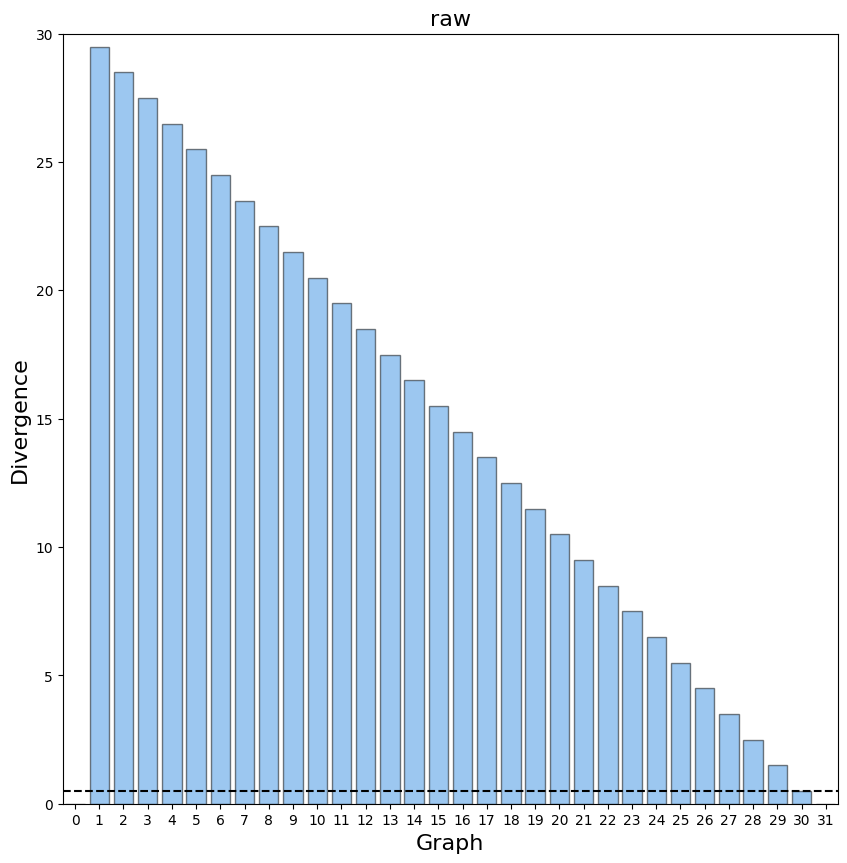

raw
Mean Standard Error: 267.34375
Spearman Rank Correlation: 0.4195060602130245



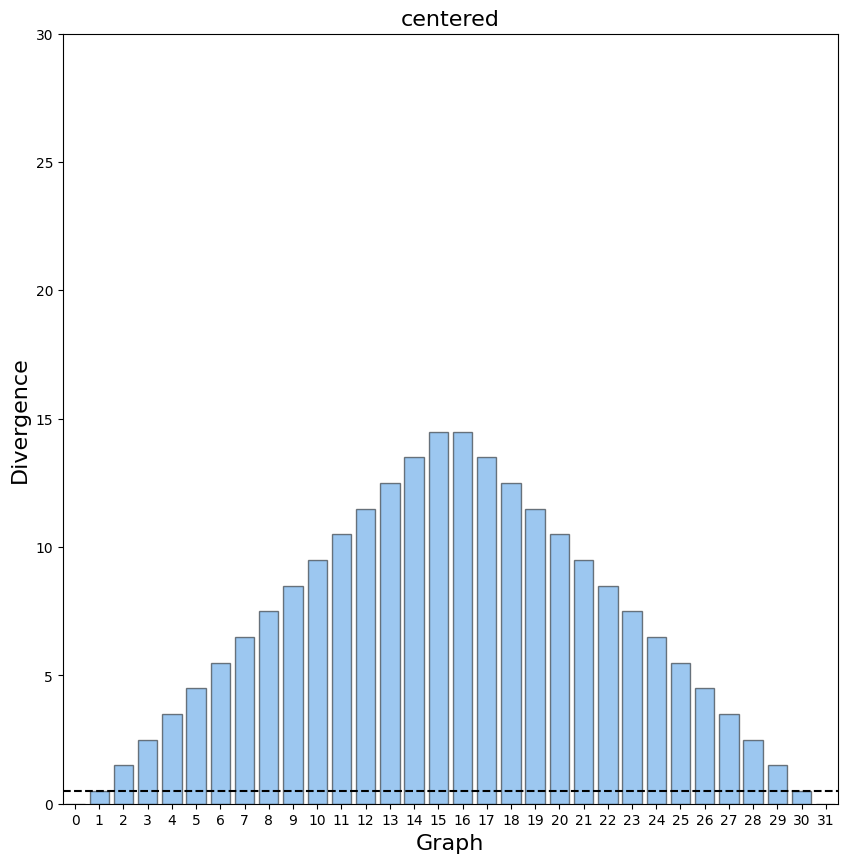

centered
Mean Standard Error: 63.4375
Spearman Rank Correlation: 0.420084025208403



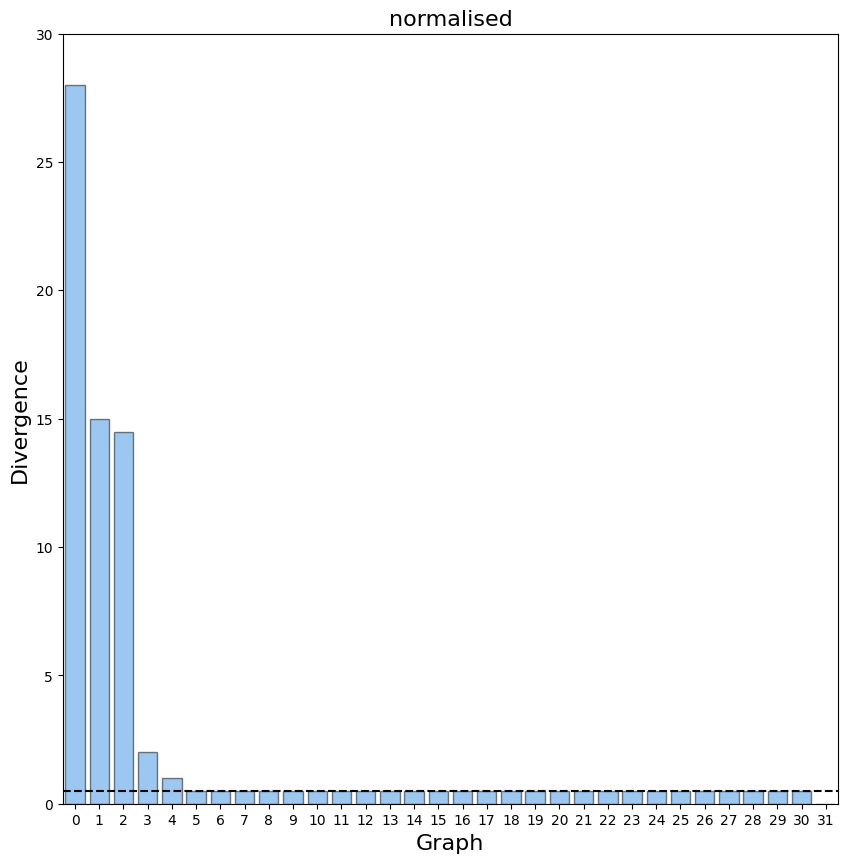

normalised
Mean Standard Error: 37.2734375
Spearman Rank Correlation: 0.0



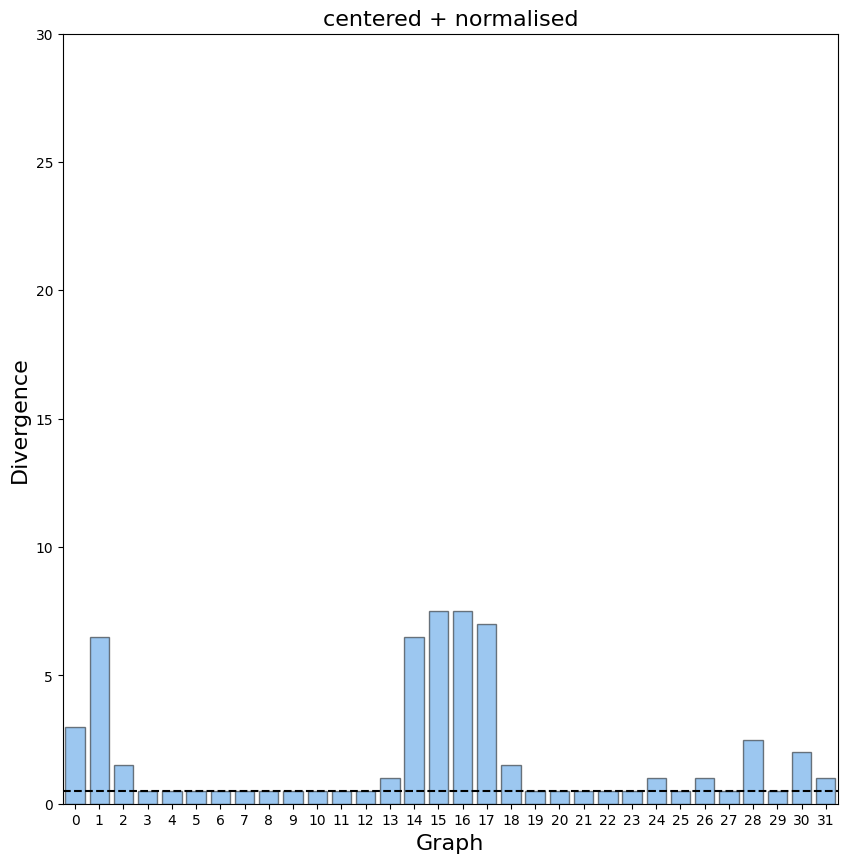

centered + normalised
Mean Standard Error: 7.2265625
Spearman Rank Correlation: -0.2238898339052519



In [39]:
# Initialise uMAP results
df_umap = pd.DataFrame()

# Define embedding list
list_embeddings = [emb_raw, emb_center, emb_norm, emb_centernorm]
list_labels = ['raw', 'centered', 'normalised', 'centered + normalised']

# Iterate over embedding types
for emb_type, label in zip(list_embeddings, list_labels):
    # Run umap
    df_emb = umap_get_embeddings(emb_type, list_pyg)
    # Add column
    df_emb['emb_type'] = label
    # Concatenate
    df_umap = pd.concat([df_umap, df_emb])

# # Iterate over embedding types
# for emb_type in list_labels:
#     # Slice dataframe
#     df_slice = df_umap[df_umap['emb_type'] == emb_type]
#     # Visualise
#     umap_visualise(df_slice, title = emb_type)

# Iterate over vectors
for emb_type, label in zip(list_embeddings, list_labels):
    # Generate similarity matrices
    sim_matrix = emb_type @ emb_type.t()
    # Generate distance matrix
    dist_matrix = 1.0 - sim_matrix
    # Fill diagonal
    dist_matrix.fill_diagonal_(float('inf'))

    # Generate dictionary of expected neighbours
    expected_neighbors = {
        i: [j for j in [i-1, i+1] if 0 <= j < len(emb_type)]
        for i in range(len(emb_type))
    }
    # Calculate actual ranking
    actual_ranks = torch.argsort(dist_matrix, dim=1)
    
    # Define ideal scores
    #ideal_scores = [0.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.0]
    ideal_scores = [0] + [0.5] * (N_GRAPHS - 2) + [0]

    # Initialise divergence score list
    list_divergence = []
    # Iterate over vector
    for i in range(len(emb_type)):
        expected = expected_neighbors[i]
        actual = actual_ranks[i].tolist()
        # Get rank positions of expected neighbors
        ranks = [actual.index(j) for j in expected]
        # Lower rank = closer; ideal ranks are [0, 1]
        divergence = sum(ranks) / len(ranks)  # average rank of expected neighbors
        list_divergence.append(divergence)

    # Calculate mean squared error
    mse = np.mean((np.array(list_divergence) - np.array(ideal_scores))**2)
    src = spearmanr(list_divergence, ideal_scores).correlation

    # Visualise divergence
    plt.figure(figsize = (10,10))
    plt.title(f'{label}', fontsize = 16)
    sns.barplot(list_divergence, color = 'dodgerblue', edgecolor = 'black', alpha = 0.5)
    plt.axhline(y = 0.5, linestyle = 'dashed', color = 'black')
    plt.ylim(0,30)
    plt.ylabel('Divergence', fontsize = 16)
    plt.xlabel('Graph', fontsize = 16)
    plt.show()

    # Report
    print(f'{label}')
    # Low is better
    print(f'Mean Standard Error: {mse}')
    # High is better
    print(f'Spearman Rank Correlation: {src}')
    print()

### uMAP

#### Run uMAP

In [311]:
# # uMAP embedding
# umap_embedding = umap.UMAP(metric = 'cosine').fit_transform(embeddings)
# # Get mean dexp expression per graph
# list_dexp = [graph.mean for graph in list_pyg]

# # Convert to dataframe
# df_umap = pd.DataFrame(umap_embedding, columns = ['x', 'y'])
# df_umap['mean_dexp'] = list_dexp

# # Show data
# df_umap.head()

In [25]:
df_umap.head()

,x,y,mean_dexp,emb_type
0,5.872547,9.229284,0.0,raw
1,6.403586,8.882901,1.0,raw
2,6.199006,8.006867,2.0,raw
3,5.505826,8.215902,3.0,raw
4,4.971822,7.811681,4.0,raw


#### Visualise

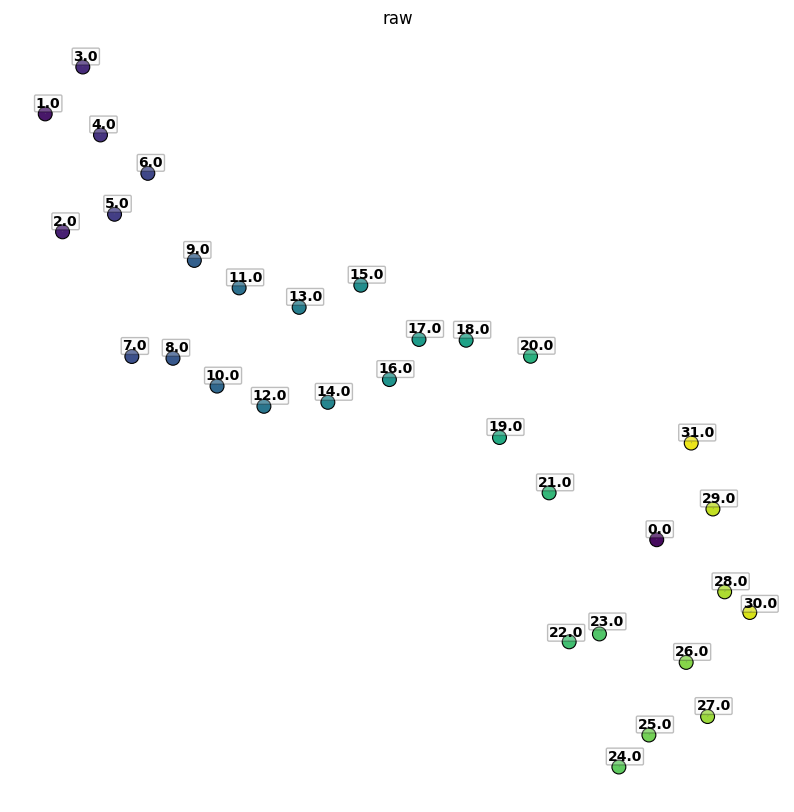

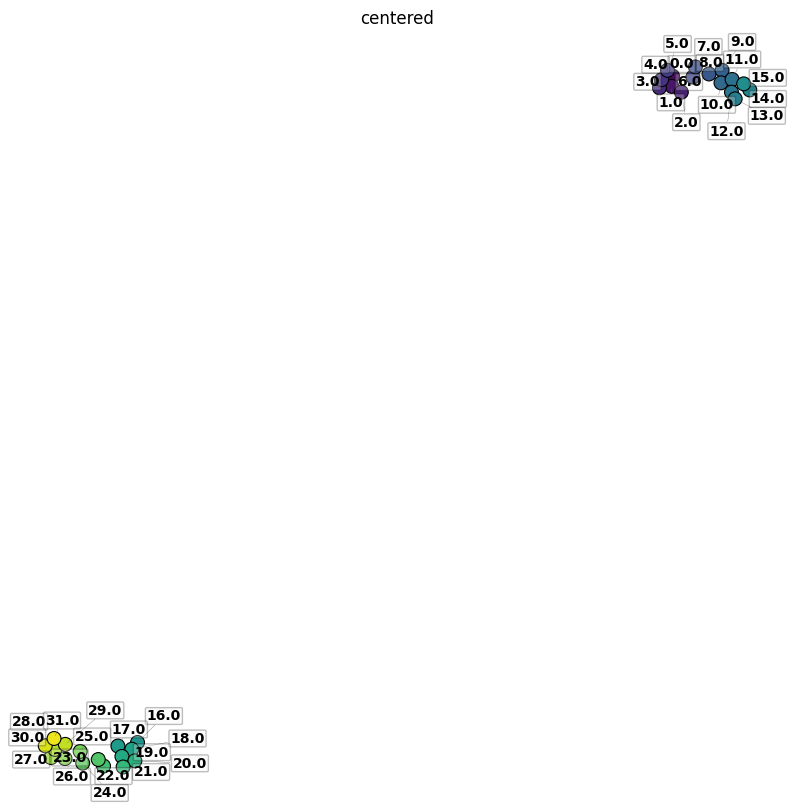

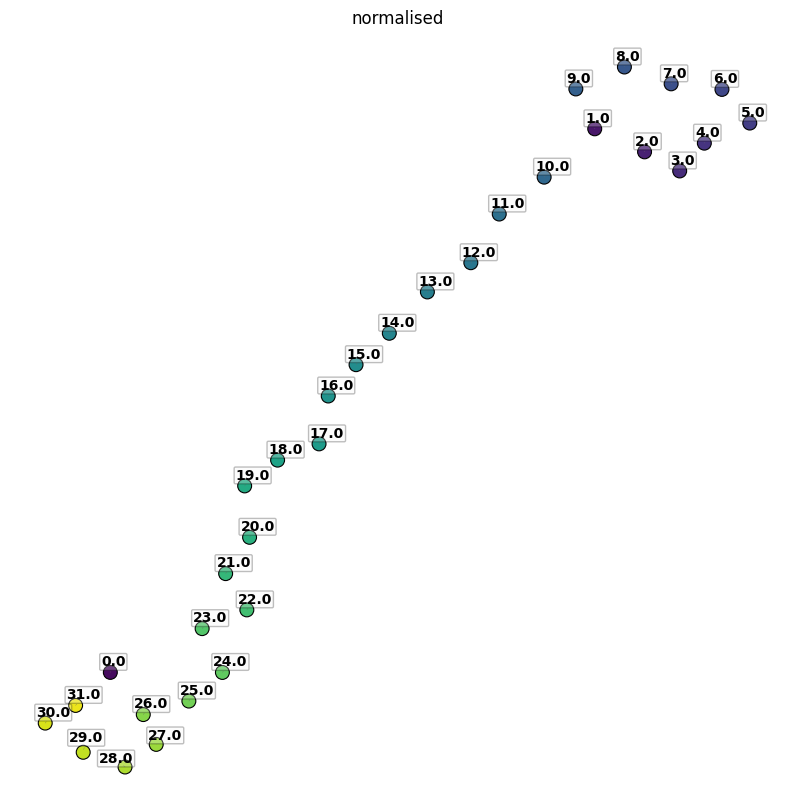

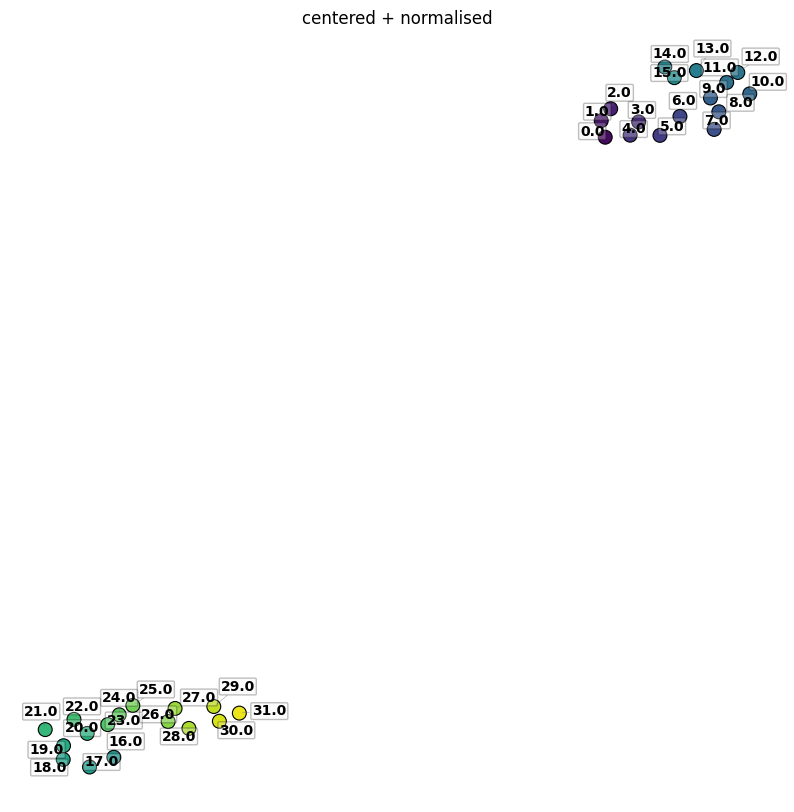

In [45]:
# Iterate through emb_type
for type in pd.unique(df_umap['emb_type']):
    df_slice = df_umap[df_umap['emb_type'] == type]

    plt.figure(figsize = (10,10))
    plt.title(f'{type}')
    sns.scatterplot(df_slice, x = 'x', y = 'y', hue = 'mean_dexp', palette = 'viridis', alpha = 1, edgecolor = 'black', s = 100)
    plt.legend().remove()

    # Initialise labels
    list_labels = []

    # Iterate through df_slice
    for index, row in df_slice.iterrows():
        # Get label data
        label = row['mean_dexp']
        # Get coordinates
        x,y = row['x'], row['y']

        # Label style
        label_style = {'fontsize' : 10,
                    'weight' : 'bold',
                    'color' : 'black',
                    'alpha' : 1,
                    'ha' : 'center',
                    'va' : 'bottom',
                    'bbox' : {'facecolor' : 'whitesmoke',
                                'edgecolor' : 'black',
                                'alpha' : 0.25,
                                'boxstyle' : 'round, pad = 0.1'}}

        # Append data w/ styling
        list_labels.append(plt.text(x, y, label, **label_style))

    # Plot labels
    adjust_text(list_labels, 
                arrowprops = dict(arrowstyle = '-',
                                color = 'dimgrey',
                                lw = 0.25));
    # Remove axis
    plt.axis('off');

### Similarity matrix

In [313]:
# # Generate cosine similarity matrix
# similarity_matrix = embeddings @ embeddings.t()

# # Get number of graphs
# num_graphs = similarity_matrix.size(0)
# # Copy matrix
# matrix_copy = similarity_matrix.clone()
# # Fill diagonal with -inf values
# matrix_copy.fill_diagonal_(-float('inf'))
# # Get nearest index to each graph
# nearest_index = matrix_copy.argmax(dim = 1)

# nearest_index

## GIN + contrastive learning